# Unsupervised Anomaly Detection for Network Intrusion Detection

**Author:** Pooja Chavan Patil  
**Date:** August 2026  
**Environment:** Python (conda env:base) | Scikit-Learn, PyTorch/Keras, Plotly  
**Dataset:** CICIDS-2017 (Network Traffic Subsets: Tuesday, DDoS, PortScan, Bot)

## Executive Summary

### Objective
To evaluate and benchmark classical vs. neural unsupervised anomaly detection models in identifying malicious network traffic without relying on labeled training data.

### Methodology & Workflow
1. **Data Preprocessing & Aggregation:** Combined network traffic logs across multiple attack categories (DDoS, PortScan, FTP-Patator, SSH-Patator, Bot) and scaled features across 68 network attributes.
2. **Model Training:** Trained five unsupervised anomaly detection algorithms solely on baseline traffic:
   * **Classical Statistical/Geometric:** Principal Component Analysis (PCA), Isolation Forest, Local Outlier Factor (LOF), One-Class SVM.
   * **Deep Learning:** Deep Autoencoder (Reconstruction Error-based detection).
3. **Evaluation Metrics:** Evaluated models using Precision-Recall (PR) curves, Average Precision (AP) scores, and per-attack class detection heatmaps.
4. **Dimensionality Reduction & Visualization:** Projected 68-dimensional traffic features into 2D space using PCA to visualize clustering behavior and feature overlap per attack vector.

### Key Conclusions
* **Best Overall:** **Autoencoder (AP = 0.769)** demonstrated the highest overall precision-recall balance and superior detection on high-volume and brute-force attacks (FTP-Patator: 100%, PortScan: 100%, DDoS: 86%).
* **Specialized Strengths:** **LOF** uniquely captured **SSH-Patator (97%)**, where other models failed, making it an optimal candidate for hybrid/ensemble architectures.
* **Core Limitation:** Unsupervised models universally struggled with **Bot traffic (<29% detection)** due to severe feature-space overlap with benign traffic in low dimensions.

## imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve)
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve
import plotly.express as px
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## loading the cleaned 5 files 

In [2]:
path = "/Users/chima/SecurITe_project/Cleaned_files/"

monday   = pd.read_csv(path + "monday_clean.csv")
tuesday  = pd.read_csv(path + "Tuesday_Patator_clean.csv")
ddos     = pd.read_csv(path + "friday_DDoS_clean.csv")
portscan = pd.read_csv(path + "friday_portscan_clean.csv")
bot      = pd.read_csv(path + "friday_Mrg_bot_clean.csv")

# removing spaces from column names
for df in [monday, tuesday, ddos, portscan, bot]:
    df.columns = df.columns.str.strip()

print("monday  ", monday.shape)
print("tuesday ", tuesday.shape)
print("ddos    ", ddos.shape)
print("portscan", portscan.shape)
print("bot     ", bot.shape)

monday   (528831, 79)
tuesday  (445068, 79)
ddos     (225574, 80)
portscan (285845, 79)
bot      (190655, 79)


## Monday is for training, other 4 are testing

In [3]:
monday.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
# checking if any nulls
print(monday.isnull().sum().sum())
print(np.isinf(monday.select_dtypes(include=np.number)).sum().sum())

0
0


monday labels: ['BENIGN']

Label
BENIGN         844531
PortScan       158804
DDoS           128006
FTP-Patator      7938
SSH-Patator      5897
Bot              1966
Name: count, dtype: int64


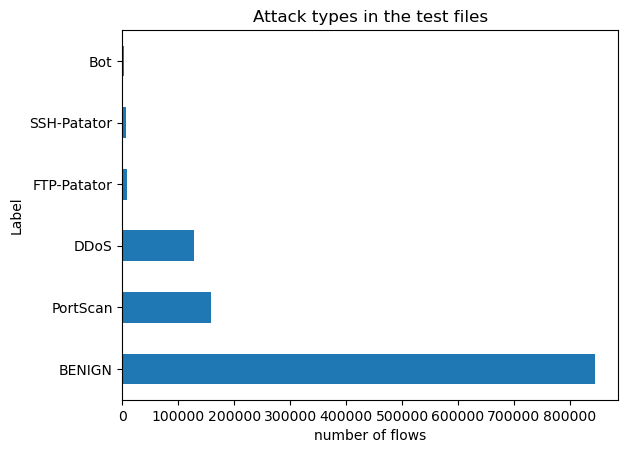

In [5]:
# monday = only benign, so we train on it
# other 4 files have the attacks, so we test on them
test_all = pd.concat([tuesday, ddos, portscan, bot], ignore_index=True)

print("monday labels:", monday['Label'].unique())
print()
print(test_all['Label'].value_counts())

# plot the attack distribution
test_all['Label'].value_counts().plot(kind='barh')
plt.title('Attack types in the test files')
plt.xlabel('number of flows')
plt.show()

Monday has only BENIGN, which is why it works as the training set — the model
learns what normal traffic looks like and never sees an attack.

The attack counts are very uneven. PortScan and DDoS have over 100k rows each,
but Bot has under 2,000. So Bot is only about 0.17% of the test data. Any average
score across all attacks will basically ignore Bot, so I need to look at each
attack separately later.

## Taking only samples 

In [6]:
N_TRAIN = 50000
N_TEST  = 200000

train = monday.sample(n=N_TRAIN, random_state=42)
test  = test_all.sample(n=N_TEST, random_state=42)   # always sample from test_all

# labels only for checking later, NOT for training
y_test = (test['Label'] != 'BENIGN').astype(int)
attack_type = test['Label'].values

print("train:", train.shape, " test:", test.shape)
print("anomaly rate: %.2f%%" % (100 * y_test.mean()))

train: (50000, 79)  test: (200000, 80)
anomaly rate: 26.35%


## making the feature matrix

In [7]:
drop_cols = ['Label', 'Label_num']   # Label_num is in the ddos file, must drop it

def get_features(df):
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    X = X.replace([np.inf, -np.inf], np.nan)   # some columns have inf
    return X

X_train_raw = get_features(train)
X_test_raw  = get_features(test)

# fill missing values with median from TRAIN only
medians = X_train_raw.median()
X_train_raw = X_train_raw.fillna(medians)
X_test_raw  = X_test_raw.fillna(medians)

# drop columns that are all same value
keep = X_train_raw.columns[X_train_raw.nunique() > 1]
X_train_raw = X_train_raw[keep]
X_test_raw  = X_test_raw[keep]

print("features used:", len(keep))

features used: 68


## scaling

In [8]:
# these features have very big outliers, so QuantileTransformer works
# better here than StandardScaler


scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_train = scaler.fit_transform(X_train_raw)   # fit on monday only
X_test  = scaler.transform(X_test_raw)

print(X_train.shape, X_test.shape)

(50000, 68) (200000, 68)


I used QuantileTransformer instead of StandardScaler because these features have
huge outliers Flow Duration goes from 0 to over 100 million. With StandardScaler
those few extreme rows dominate all the distance calculations, which hurts LOF,
One-Class SVM and PCA.

## Model 1: Isolation Forest

In [9]:
scores_train = {}
scores_test  = {}

iso = IsolationForest(n_estimators=200, max_samples=8192, random_state=42, n_jobs=-1)
iso.fit(X_train)

# score_samples gives HIGH value for normal, so we put minus
# now high score = more anomaly (same for all models below)
scores_train['IsolationForest'] = -iso.score_samples(X_train)
scores_test['IsolationForest']  = -iso.score_samples(X_test)
print("done")

done


## Model 2: One-Class SVM

In [10]:
svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
svm.fit(X_train)

scores_train['OneClassSVM'] = -svm.decision_function(X_train)
scores_test['OneClassSVM']  = -svm.decision_function(X_test)
print("done")

done


## Model 3: Local Outlier Factor

In [11]:
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1)
lof.fit(X_train)

scores_train['LOF'] = -lof.score_samples(X_train)
scores_test['LOF']  = -lof.score_samples(X_test)
print("done")

done


## Model 4: PCA reconstruction error

In [12]:
pca = PCA(n_components=0.95, random_state=42)
pca.fit(X_train)

# normal traffic should rebuild well, attacks should not
def pca_error(X):
    return np.mean((X - pca.inverse_transform(pca.transform(X)))**2, axis=1)

scores_train['PCA'] = pca_error(X_train)
scores_test['PCA']  = pca_error(X_test)
print("components kept:", pca.n_components_)

components kept: 12


## Model 5: Autoencoder

In [13]:
# autoencoder = neural net that learns to output its own input
# using MLPRegressor so we don't need tensorflow/pytorch
ae = MLPRegressor(hidden_layer_sizes=(64, 32, 8, 32, 64),
                  activation='relu', solver='adam',
                  max_iter=60, random_state=42)
ae.fit(X_train, X_train)

def ae_error(X):
    return np.mean((X - ae.predict(X))**2, axis=1)

scores_train['Autoencoder'] = ae_error(X_train)
scores_test['Autoencoder']  = ae_error(X_test)
print("done")

done


All 5 models are trained only on Monday. None of them ever saw a label.
Isolation Forest: rows that are easy to separate with random splits
- One-Class SVM: rows outside the boundary drawn around normal data
- LOF: rows sitting in a low-density area compared to their neighbours
- PCA: rows that don't rebuild well from the main components
- Autoencoder: same idea as PCA but the neural net can learn non-linear patterns

Note: I flipped the sign on the first three so that for every model, a higher score
means more likely to be an attack.

## Evaluating  all models

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
preds = {}

for name in scores_test:
    s_train = scores_train[name]
    s_test = scores_test[name]

    # threshold comes from train scores only, so no labels are used here
    threshold = np.percentile(s_train, 95)
    y_pred = (s_test > threshold).astype(int)
    preds[name] = y_pred

    row = {}
    row['model'] = name
    row['accuracy'] = accuracy_score(y_test, y_pred)

    # macro average
    row['precision_macro'] = precision_score(y_test, y_pred, average='macro', zero_division=0)
    row['recall_macro'] = recall_score(y_test, y_pred, average='macro', zero_division=0)
    row['f1_macro'] = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # micro average
    row['precision_micro'] = precision_score(y_test, y_pred, average='micro', zero_division=0)
    row['recall_micro'] = recall_score(y_test, y_pred, average='micro', zero_division=0)
    row['f1_micro'] = f1_score(y_test, y_pred, average='micro', zero_division=0)

    # weighted average
    row['precision_weighted'] = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    row['recall_weighted'] = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    row['f1_weighted'] = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # only for the attack class
    row['precision_anomaly'] = precision_score(y_test, y_pred, zero_division=0)
    row['recall_anomaly'] = recall_score(y_test, y_pred, zero_division=0)
    row['f1_anomaly'] = f1_score(y_test, y_pred, zero_division=0)

    # these two use the raw scores, not the 0/1 prediction
    row['roc_auc'] = roc_auc_score(y_test, s_test)
    row['pr_auc'] = average_precision_score(y_test, s_test)

    results.append(row)

results = pd.DataFrame(results)
results = results.sort_values('pr_auc', ascending=False)

results[['model', 'roc_auc', 'pr_auc', 'accuracy', 'f1_weighted', 'f1_macro', 'f1_micro']]

,model,roc_auc,pr_auc,accuracy,f1_weighted,f1_macro,f1_micro
4,Autoencoder,0.948521,0.768984,0.902525,0.905115,0.881501,0.902525
3,PCA,0.925119,0.707933,0.880260,0.881312,0.848486,0.880260
0,IsolationForest,0.924408,0.689765,0.834740,0.833137,0.783018,0.834740
2,LOF,0.884836,0.588320,0.842855,0.850079,0.818970,0.842855
1,OneClassSVM,0.826008,0.560415,0.808590,0.803573,0.740945,0.808590


## Anomaly class scores

In [15]:
results[['model','precision_anomaly','recall_anomaly','f1_anomaly']]

,model,precision_anomaly,recall_anomaly,f1_anomaly
4,Autoencoder,0.763172,0.913475,0.831587
3,PCA,0.757905,0.801518,0.779102
0,IsolationForest,0.697709,0.657639,0.677082
2,LOF,0.642380,0.910268,0.753214
1,OneClassSVM,0.659699,0.564794,0.608569


## how many of each attack did we catch

In [16]:
rows = []
for name in scores_test:
    row = {'model': name}
    for a in ['DDoS','PortScan','Bot','FTP-Patator','SSH-Patator']:
        mask = attack_type == a
        row[a] = preds[name][mask].mean()
    rows.append(row)

pd.DataFrame(rows).set_index('model').round(3)

,DDoS,PortScan,Bot,FTP-Patator,SSH-Patator
model,,,,,
IsolationForest,0.851,0.562,0.292,0.014,0.006
OneClassSVM,0.704,0.508,0.020,0.010,0.009
LOF,0.838,0.997,0.020,0.525,0.971
PCA,0.637,0.996,0.286,0.305,0.009
Autoencoder,0.858,0.997,0.017,0.998,0.102


## ROC curve

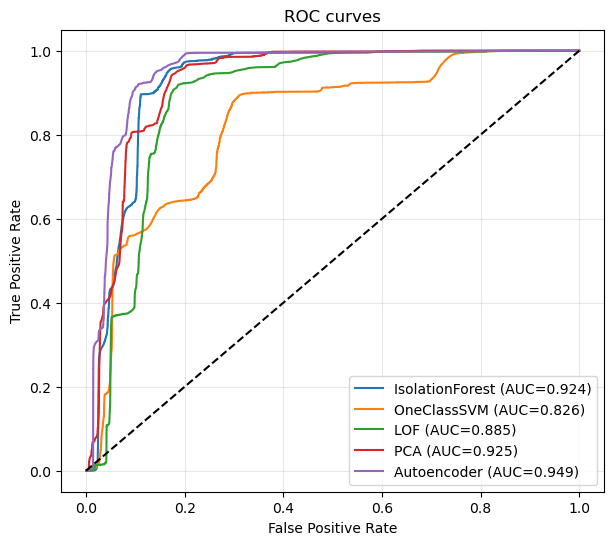

In [17]:
plt.figure(figsize=(7,6))
for name in scores_test:
    fpr, tpr, _ = roc_curve(y_test, scores_test[name])
    auc = roc_auc_score(y_test, scores_test[name])
    plt.plot(fpr, tpr, label="%s (AUC=%.3f)" % (name, auc))

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## confusion matrix

In [18]:
for name in scores_test:
    tn, fp, fn, tp = confusion_matrix(y_test, preds[name]).ravel()
    print("%-16s TN=%-7d FP=%-7d FN=%-7d TP=%-7d" % (name, tn, fp, fn, tp))

IsolationForest  TN=132297  FP=15013   FN=18039   TP=34651  
OneClassSVM      TN=131959  FP=15351   FN=22931   TP=29759  
LOF              TN=120609  FP=26701   FN=4728    TP=47962  
PCA              TN=133820  FP=13490   FN=10458   TP=42232  
Autoencoder      TN=132374  FP=14936   FN=4559    TP=48131  


## Score distribution.

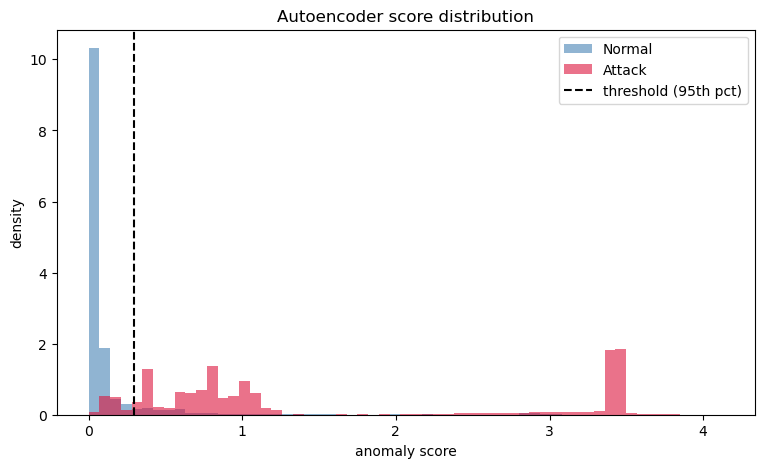

In [19]:
name = 'Autoencoder'
s_tr, s_te = scores_train[name], scores_test[name]

plt.figure(figsize=(9,5))
bins = np.linspace(0, np.percentile(s_te, 99), 60)
plt.hist(s_te[y_test==0], bins=bins, alpha=0.6, density=True, label='Normal', color='steelblue')
plt.hist(s_te[y_test==1], bins=bins, alpha=0.6, density=True, label='Attack', color='crimson')
plt.axvline(np.percentile(s_tr, 95), color='k', ls='--', label='threshold (95th pct)')
plt.xlabel('anomaly score'); plt.ylabel('density')
plt.title(name + ' score distribution'); plt.legend()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Threshold sweep — shows the precision/recall tradeoff and where F1 peaks

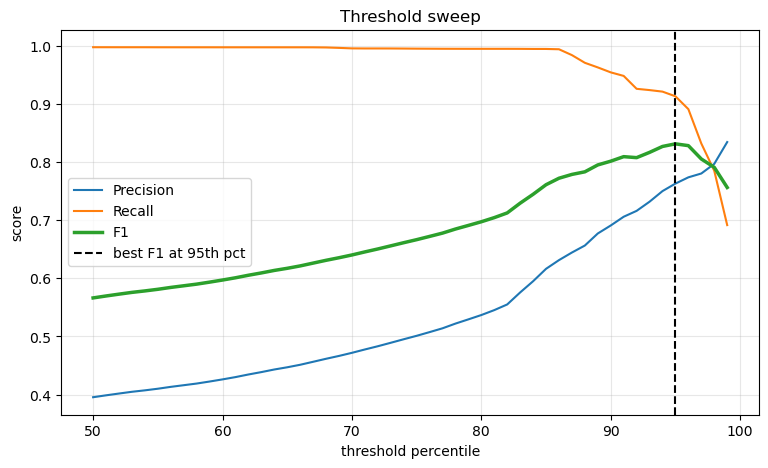

In [20]:
pcts = np.arange(50, 100)
precs, recs, f1s = [], [], []
for p in pcts:
    yp = (s_te > np.percentile(s_tr, p)).astype(int)
    tp = ((yp==1)&(y_test==1)).sum()
    fp = ((yp==1)&(y_test==0)).sum()
    fn = ((yp==0)&(y_test==1)).sum()
    pr = tp/(tp+fp) if tp+fp else 0
    rc = tp/(tp+fn) if tp+fn else 0
    precs.append(pr); recs.append(rc)
    f1s.append(2*pr*rc/(pr+rc) if pr+rc else 0)

plt.figure(figsize=(9,5))
plt.plot(pcts, precs, label='Precision')
plt.plot(pcts, recs, label='Recall')
plt.plot(pcts, f1s, label='F1', lw=2.5)
best = pcts[int(np.argmax(f1s))]
plt.axvline(best, color='k', ls='--', label='best F1 at %dth pct' % best)
plt.xlabel('threshold percentile'); plt.ylabel('score')
plt.title('Threshold sweep'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

Every model looks strong here (AUC 0.83–0.95), noticeably better than they look on
the PR curve.

In [21]:
## PR Curve

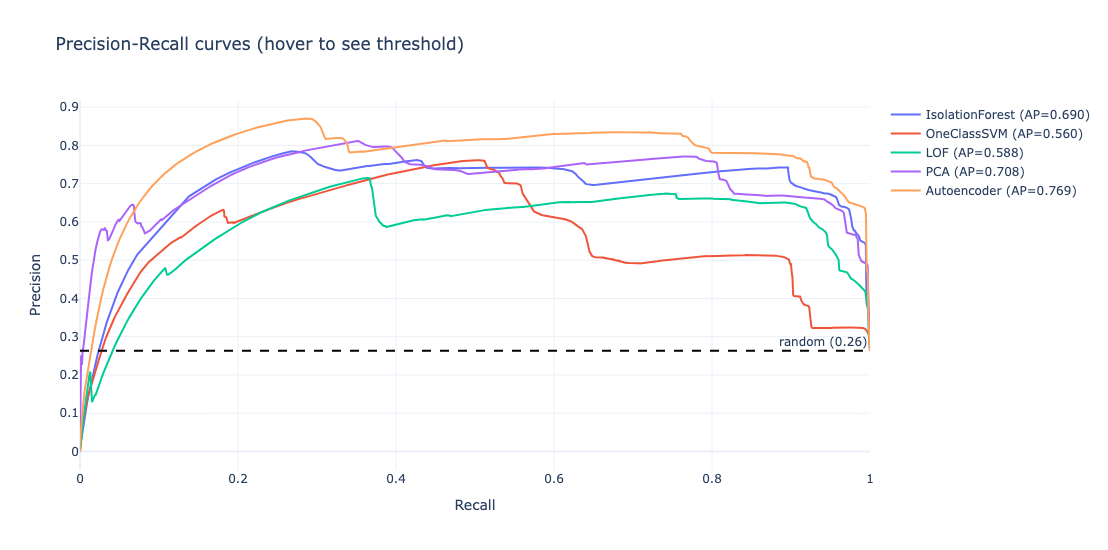

In [22]:
fig = go.Figure()

for name in scores_test:
    prec, rec, thr = precision_recall_curve(y_test, scores_test[name])
    ap = average_precision_score(y_test, scores_test[name])

    # precision_recall_curve returns one extra point that has no threshold
    prec = prec[:-1]
    rec = rec[:-1]

    # too many points makes the plot slow, so take every Nth
    step = max(1, len(prec) // 1500)
    prec = prec[::step]
    rec = rec[::step]
    thr = thr[::step]

    f1 = 2 * prec * rec / (prec + rec + 1e-12)

    fig.add_trace(go.Scatter(
        x=rec, y=prec, mode='lines',
        name="%s (AP=%.3f)" % (name, ap),
        customdata=np.stack([thr, f1], axis=-1),
        hovertemplate=('Recall %{x:.3f}<br>'
                       'Precision %{y:.3f}<br>'
                       'F1 %{customdata[1]:.3f}<br>'
                       'threshold %{customdata[0]:.4f}'
                       '<extra>%{fullData.name}</extra>')))

fig.add_hline(y=y_test.mean(), line_dash='dash', line_color='black',
              annotation_text='random (%.2f)' % y_test.mean())

fig.update_layout(title='Precision-Recall curves (hover to see threshold)',
                  xaxis_title='Recall', yaxis_title='Precision',
                  width=800, height=550, template='plotly_white')
fig.show()
fig.write_html('pr_curve_interactive.html', include_plotlyjs='cdn')

Top Performer: Autoencoder achieves the highest overall performance
Secondary Models: PCA (AP = 0.708) and Isolation Forest (AP = 0.690)
Weaker Baselines: LOF (AP = 0.588) and OneClassSVM (AP = 0.560)

## Per-attack heatmap

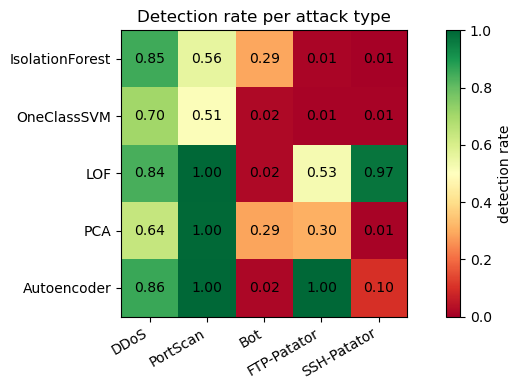

In [23]:
import matplotlib.pyplot as plt
tab = pd.DataFrame(rows).set_index('model')   # from Cell 14

fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(tab.values, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(tab.columns)), tab.columns, rotation=30, ha='right')
ax.set_yticks(range(len(tab.index)), tab.index)
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        ax.text(j, i, "%.2f" % tab.values[i,j], ha='center', va='center')
plt.colorbar(im, label='detection rate')
plt.title('Detection rate per attack type')
plt.tight_layout(); plt.savefig('per_attack_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

1.High-Volume Attacks are Easy to Detect like DDOs :Successfully detected by almost all models 
2.PortScan: Perfect detection.
    
Targeted Brute-Force Attacks Show Mixed Results
3.FTP-Patator: Autoencoder achieves perfect detection (1.00), while LOF reaches 0.53 and PCA gets 0.30. Isolation Forest and OneClassSVM completely fail to catch it (0.01).
4.SSH-Patator: LOF dominates here with a 0.97 detection rate. Other models struggles.

5.Bot Traffic is Hardest to Detect


In [24]:
viz = PCA(n_components=2, random_state=42).fit(X_train)
sub = np.random.choice(len(X_test), 5000, replace=False)
Z = viz.transform(X_test[sub])

df_plot = pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
                        'attack': attack_type[sub],
                        'score': s_te[sub]})
fig = px.scatter(df_plot, x='PC1', y='PC2', color='attack',
                 hover_data=['score'], opacity=0.6,
                 title='Traffic in 2D (PCA), coloured by attack type')
fig.show()
fig.write_html('pca_scatter_interactive.html', include_plotlyjs='cdn')

In [25]:
viz = PCA(n_components=2, random_state=42).fit(X_train)

# take a fixed number from each class, otherwise the rare attacks
# get almost no points and you can't see them at all
rng = np.random.default_rng(42)
cap = {'BENIGN': 4000, 'DDoS': 1200, 'PortScan': 1200,
       'FTP-Patator': 800, 'SSH-Patator': 800, 'Bot': 800}

sub = []
for a in cap:
    w = np.where(attack_type == a)[0]
    if len(w) > 0:
        sub.append(rng.choice(w, size=min(cap[a], len(w)), replace=False))
sub = np.concatenate(sub)

Z = viz.transform(X_test[sub])

colors = {'BENIGN': '#B0B7C3', 'DDoS': '#E4572E', 'PortScan': '#17BEBB',
          'FTP-Patator': '#A24BCF', 'SSH-Patator': '#F4A259', 'Bot': '#2E86FF'}

fig = go.Figure()
# benign first so the attacks get drawn on top of it
for a in ['BENIGN', 'DDoS', 'PortScan', 'FTP-Patator', 'SSH-Patator', 'Bot']:
    m = attack_type[sub] == a
    if m.sum() == 0:
        continue
    fig.add_trace(go.Scattergl(
        x=Z[m, 0], y=Z[m, 1], mode='markers',
        name="%s (%d)" % (a, m.sum()),
        marker=dict(size=4 if a == 'BENIGN' else 7,
                    color=colors[a],
                    opacity=0.35 if a == 'BENIGN' else 0.85,
                    line=dict(width=0)),
        customdata=s_te[sub][m],
        hovertemplate='PC1 %{x:.2f}<br>PC2 %{y:.2f}<br>score %{customdata:.4f}'
                      '<extra>' + a + '</extra>'))

fig.update_layout(title='Traffic in 2D (PCA), coloured by attack type',
                  xaxis_title='PC1', yaxis_title='PC2',
                  width=1250, height=650, template='plotly_white',
                  legend=dict(orientation='h', yanchor='bottom', y=-0.22,
                              xanchor='center', x=0.5))
fig.show()
fig.write_html('pca_scatter_interactive.html', include_plotlyjs='cdn')

The dense cluster on the right is DDoShat matches DDoS being one of the easier attacks to detect.
PortScan does not form one big cluster here, it appears as several small tight
groups.
    Bot points sit right on top of the normal traffic with no separation at all,
Note this is only 2 of 68 dimensions.

    Unsupervised models overall struggle with Bot traffic, likely because bot activity closely mirrors benign behavioral patterns in the feature space.